In [15]:
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

from data import CUBConceptDataset, collate_fn_with_raw_images
from nets import PPConceptNet
from PIL import Image
import numpy as np
import cv2

def overlay_attn_map(attn_map: np.ndarray, im: Image.Image):
    """
    attn_map: np.ndarray of shape `(H, W,)`, same as im, values can be unormalized
    im: a PIL image of width H and height W
    """
    im = np.array(im.resize((224, 224), Image.BILINEAR))

    max_val, min_val = np.max(attn_map), np.min(attn_map)
    attn_map = (attn_map - min_val) / (max_val - min_val)
    heatmap = cv2.applyColorMap((255 * attn_map).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return (0.5 * heatmap + 0.5 * im).astype(np.uint8)


In [6]:
data_dir = os.path.expanduser("~/Developer/Research/datasets")
transforms = Compose([
    Resize((224, 224,)),
    ToTensor(),
    Normalize((0.485, 0.456, 0.406,), (0.229, 0.224, 0.225,)),
])

with open('data/CUB/cub_attributes_cleaned_selected.txt', 'r') as fp:
    concept_texts = fp.read().splitlines()

train_dataset = CUBConceptDataset(
    Path(data_dir) / 'cub200_cropped' / 'train_cropped',
    transforms=transforms,
    return_attributes=True,
    return_img_path=True
)

test_dataset = CUBConceptDataset(
    Path(data_dir) / 'cub200_cropped' / 'test_cropped',
    transforms=transforms,
    return_attributes=True,
    return_img_path=True
)
num_classes, num_concepts = 200, 112
batch_size = 16
train_loader = DataLoader(train_dataset, collate_fn=collate_fn_with_raw_images, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, collate_fn=collate_fn_with_raw_images, batch_size=batch_size, shuffle=True)
train_loader_iter = iter(train_loader)
test_loader_iter = iter(test_loader)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PPConceptNet(num_classes=num_classes, backbone_name="densenet121", use_mask=True)

checkpoint = torch.load('checkpoints/model_epoch6.pth')
model.load_state_dict(checkpoint['state_dict'])

# method 1
prototype_to_concept_indices = model.prototype_to_concept.data.argmax(dim=-1).reshape(num_classes, -1)

# method 2
# prototype_semantics = torch.load("prototype_text_logits.pth", map_location="cpu")
# prototype_mean_embeddings = prototype_semantics["prototype_mean_embeddings"]
# patch_text_logits = prototype_semantics["patch_text_logits"]
# mean_emb_text_logits = torch.stack(prototype_semantics["mean_emb_text_logits"], dim=0)
# prototype_to_concept_indices = []
# for logits in patch_text_logits:
#     prototype_to_concept_indices.append(logits.mean(dim=0).argmax().item())
# prototype_to_concept_indices = torch.tensor(prototype_to_concept_indices).reshape(200, -1)

# method 3
# prototype_concept_logits_data = torch.load('all_classes_prototype_concept_logits.pth')
# all_classes_prototype_concept_logits = prototype_concept_logits_data['all_classes_prototype_concept_logits']
# prototype_to_concept_indices = []
# for i, prototype_concept_logits in enumerate(all_classes_prototype_concept_logits):
#     proto_cpt_logits = prototype_concept_logits.squeeze().softmax(dim=-1).sum(dim=1)
#     prototype_to_concept_indices.append(proto_cpt_logits.argmax(dim=-1))
# prototype_to_concept_indices = torch.stack(prototype_to_concept_indices, dim=0)

In [8]:
with torch.no_grad():
    images, labels, attributes, im_paths = next(test_loader_iter)
    logits, concept_scores, cosine_scores, cosine_activations, activations = model(images, with_concepts=True)

/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/046.Gadwall/Gadwall_0004_31669.jpg
/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/030.Fish_Crow/Fish_Crow_0072_25945.jpg
/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/068.Ruby_throated_Hummingbird/Ruby_Throated_Hummingbird_0013_57212.jpg
/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/057.Rose_breasted_Grosbeak/Rose_Breasted_Grosbeak_0059_39045.jpg
/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/060.Glaucous_winged_Gull/Glaucous_Winged_Gull_0007_44575.jpg
/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/171.Myrtle_Warbler/Myrtle_Warbler_0088_166639.jpg
/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/035.Purple_Finch/Purple_Finch_0118_27604.jpg
/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/038.Great_Crested_Flycatcher/Great_Crested_Flycatc

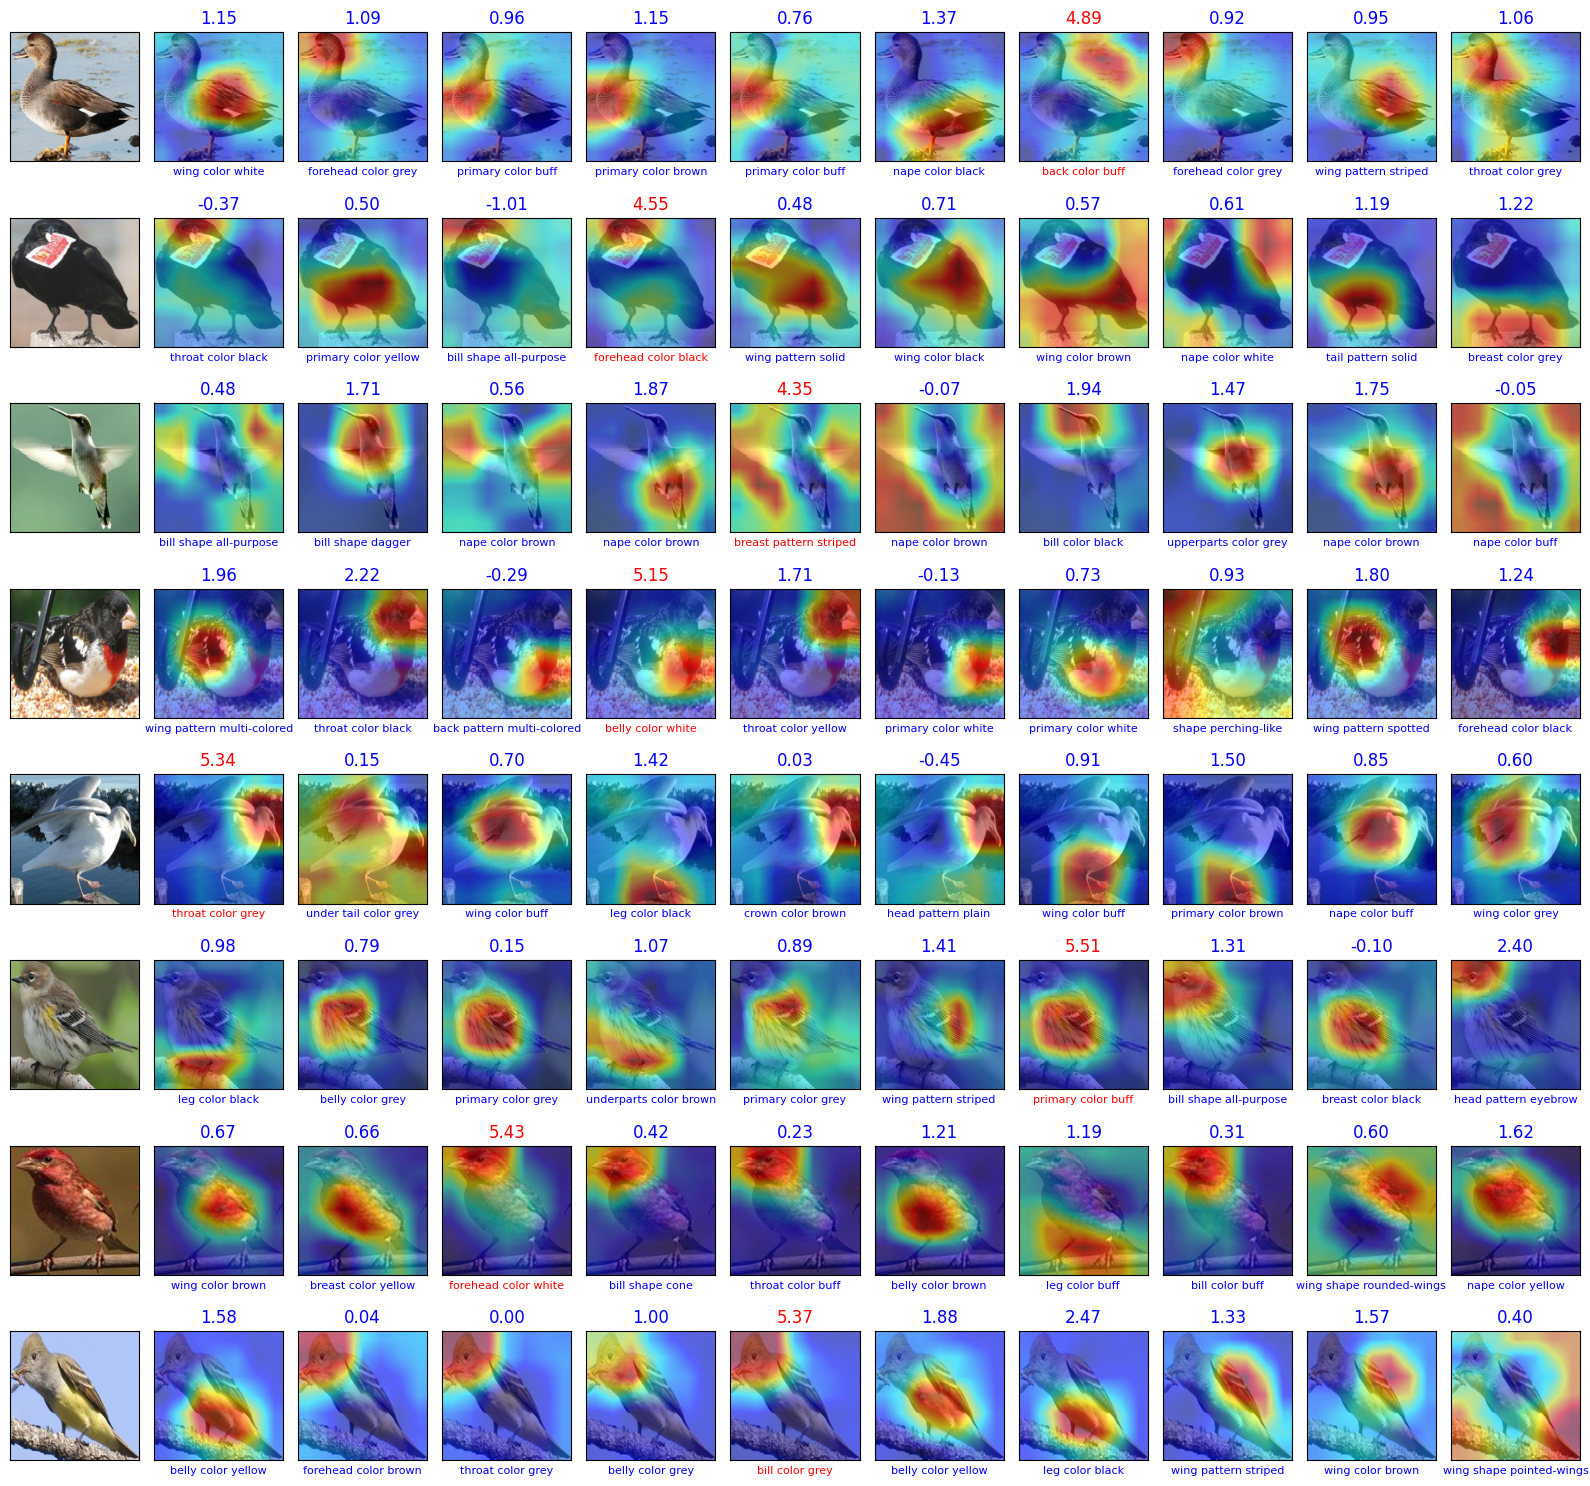

In [10]:
activation_maps = F.interpolate(activations, (224, 224), mode='bilinear').reshape(-1, 200, 10, 224, 224)
prototype_scores = F.adaptive_max_pool2d(activations, (1, 1,)).reshape(-1, 200, 10)

# raw_images_np = raw_images.cpu().numpy().transpose(0, 2, 3, 1)

fig, axes = plt.subplots(8, 11, figsize=(16, 15))
for i, (axe_row, acts, proto_scores, raw_im_path, y) in enumerate(zip(axes, activation_maps, prototype_scores, im_paths, labels)):
    print(raw_im_path)
    raw_im = Image.open(raw_im_path).convert("RGB").resize((224, 224,))
    axe_row[0].imshow(np.array(raw_im))
    axe_row[0].set_xticks([])
    axe_row[0].set_yticks([])
    max_logit_index = proto_scores[y].argmax().item()

    for k in range(0, 10):
        res = overlay_attn_map(acts[y, k].numpy(), raw_im.resize((224, 224,)))
        concept_idx = prototype_to_concept_indices[y, k].item()

        axe_row[k + 1].imshow(res)
        axe_row[k + 1].set_xticks([])
        axe_row[k + 1].set_yticks([])

        l = proto_scores[y, k].item()
        axe_row[k + 1].set_title(f"{l:.2f}", color="r" if k == max_logit_index else "b")
        axe_row[k + 1].set_xlabel(f"{concept_texts[concept_idx]}", color="r" if k == max_logit_index else "b", fontsize=8)

fig.tight_layout()
plt.show()

In [12]:
@torch.no_grad()
def inference_and_save_activations(img_path: Path | str):
    cls_idx = int(Path(img_path).parts[-2].split(".")[0]) - 1
    input_im = transforms(Image.open(img_path).convert("RGB")).unsqueeze(0)
    logits, concept_scores, cosine_scores, cosine_activations, activations = model(input_im, with_concepts=True)
    raw_img = Image.open(img_path).convert("RGB").resize((224, 224,))
    raw_img.save((Path("output_images") / f"{Path(img_path).stem}.jpg").as_posix())

    resized_activations = F.interpolate(activations, (224, 224,), mode='bilinear')
    gt_activations = resized_activations.squeeze().reshape(model.num_classes, 10, 224, 224)[cls_idx]
    for i, act in enumerate(gt_activations):
        res = overlay_attn_map(act.numpy(), raw_img)[..., ::-1]
        cv2.imwrite((Path("output_images") / f"{Path(img_path).stem}_act{i}.jpg").as_posix(), res)

        min_val = act.min()
        max_val = act.max()
        norm_map = (act - min_val) / (max_val - min_val + 1e-6)

        # Threshold
        mask = norm_map > 0.7

        ys, xs = torch.nonzero(mask, as_tuple=True)
        x_min = int(xs.min().item())
        x_max = int((xs.max().item()))
        y_min = int(ys.min().item())
        y_max = int((ys.max().item()))

        raw_img_with_bbox = cv2.rectangle(np.array(raw_img), (x_min, y_min,), (x_max, y_max,), (255, 0, 0), 3)
        cv2.imwrite((Path("output_images") / f"{Path(img_path).stem}_bbox{i}.jpg").as_posix(), raw_img_with_bbox[..., ::-1])

In [21]:
if not os.path.exists("./output_images"):
    os.mkdir("output_images")

inference_and_save_activations("/Users/zhijiezhu/Developer/Research/datasets/cub200_cropped/test_cropped/046.Gadwall/Gadwall_0004_31669.jpg")

copy_dst = '/Users/zhijiezhu/Downloads/output_images/'
if os.path.exists(copy_dst):
    shutil.rmtree(copy_dst)
shutil.copytree('./output_images', copy_dst)

'/Users/zhijiezhu/Downloads/output_images/'